# Task 4 — Weather Data Collection and Analysis

**Objective:** Collect weather data from a public API for major Polish cities
and analyze temperature and rainfall trends over the past 30 days.

**API:** Open-Meteo Historical Archive API
- Completely free, no API key required
- Returns historical weather data for any coordinates
- Fields: max/min/mean temperature, precipitation, wind speed, humidity

**Cities:** Warsaw, Kraków, Gdańsk, Wrocław, Poznań, Łódź, Katowice, Szczecin, Lublin, Białystok

**Pipeline:**
1. Fetch 30 days of historical weather data for 10 Polish cities
2. Parse JSON responses into a unified Pandas DataFrame
3. Clean and preprocess the data
4. Analyze temperature trends and rainfall patterns
5. Visualize findings with line charts, bar charts, and heatmaps

## 1. Import Libraries

In [1]:
# requests fetches weather data from the Open-Meteo API
import requests

# Pandas for storing, cleaning, and analyzing weather data
import pandas as pd
import numpy as np

# datetime for building date ranges
from datetime import datetime, timedelta

# time for polite delays between API calls
import time

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')


All libraries imported successfully.


## 2. Configure Cities and API Settings

In [4]:
# ── Polish cities with coordinates ────────────────────────────────────────────
# Open-Meteo uses latitude/longitude to identify locations.
# We provide precise coordinates for 10 major Polish cities.
CITIES = {
    'Warsaw':    {'lat': 52.2297, 'lon': 21.0122},
    'Kraków':    {'lat': 50.0647, 'lon': 19.9450},
    'Gdańsk':    {'lat': 54.3520, 'lon': 18.6466},
    'Wrocław':   {'lat': 51.1079, 'lon': 17.0385},
    'Poznań':    {'lat': 52.4064, 'lon': 16.9252},
    'Łódź':      {'lat': 51.7592, 'lon': 19.4560},
    'Katowice':  {'lat': 50.2649, 'lon': 19.0238},
    'Szczecin':  {'lat': 53.4285, 'lon': 14.5528},
    'Lublin':    {'lat': 51.2465, 'lon': 22.5684},
    'Białystok': {'lat': 53.1325, 'lon': 23.1688},
}

# ── Date range — last 30 days ─────────────────────────────────────────────────
# Open-Meteo archive API requires explicit start and end dates.
# We fetch the last 30 days of historical data for each city.
END_DATE   = datetime.now() - timedelta(days=2)  # 2 days ago (archive has slight delay)
START_DATE = END_DATE - timedelta(days=29)        # 30 days total

START_STR = START_DATE.strftime('%Y-%m-%d')
END_STR   = END_DATE.strftime('%Y-%m-%d')

# ── API configuration ─────────────────────────────────────────────────────────
# Open-Meteo archive endpoint — returns historical weather data
API_URL = 'https://archive-api.open-meteo.com/v1/archive'

# Weather variables to collect per city per day
DAILY_VARS = [
    'temperature_2m_max',        # Maximum daily temperature (°C)
    'temperature_2m_min',        # Minimum daily temperature (°C)
    'temperature_2m_mean',       # Mean daily temperature (°C)
    'precipitation_sum',         # Total daily rainfall (mm)
    'windspeed_10m_max',         # Maximum wind speed (km/h)
    'rain_sum',                  # Rain sum (mm) — excludes snow
    'snowfall_sum',              # Snowfall (cm)
]

print(f'Cities: {len(CITIES)}')
print(f'Date range: {START_STR} → {END_STR} (30 days)')
print(f'Weather variables: {len(DAILY_VARS)}')
print(f'Total API calls: {len(CITIES)}')


Cities: 10
Date range: 2026-04-12 → 2026-05-11 (30 days)
Weather variables: 7
Total API calls: 10


## 3. Fetch Weather Data

In [7]:
def fetch_city_weather(city_name: str, lat: float, lon: float) -> pd.DataFrame | None:
    """
    Fetches 30 days of historical daily weather data for one city
    from the Open-Meteo archive API.

    API returns JSON structured as:
    {
      'daily': {
        'time': ['2025-04-01', '2025-04-02', ...],
        'temperature_2m_max': [15.2, 14.8, ...],
        'precipitation_sum': [0.0, 2.4, ...],
        ...
      }
    }

    We convert this into a flat DataFrame with one row per day.
    """
    params = {
        'latitude':  lat,
        'longitude': lon,
        'start_date': START_STR,
        'end_date':   END_STR,
        'daily':      ','.join(DAILY_VARS),
        'timezone':   'Europe/Warsaw',
    }

    try:
        r = requests.get(API_URL, params=params, timeout=15)

        if r.status_code != 200:
            print(f'  [!] {city_name}: HTTP {r.status_code}')
            return None

        data = r.json()

        # Extract the daily data dictionary
        daily = data.get('daily', {})

        if not daily or 'time' not in daily:
            print(f'  [!] {city_name}: No daily data returned')
            return None

        # Build a DataFrame from the daily data
        df = pd.DataFrame(daily)

        # Add city name and coordinates as columns
        df['city']      = city_name
        df['latitude']  = lat
        df['longitude'] = lon

        # Convert time column to proper datetime
        df['time'] = pd.to_datetime(df['time'])

        print(f'  {city_name}: {len(df)} days of data fetched')
        return df

    except Exception as e:
        print(f'  [!] {city_name}: Error — {e}')
        return None


print('Function defined: fetch_city_weather()')


Function defined: fetch_city_weather()


In [9]:
# ── Fetch weather data for all cities ─────────────────────────────────────────
all_data = []

print(f'Fetching weather data for {len(CITIES)} Polish cities...')
print(f'Date range: {START_STR} → {END_STR}\n')

for city_name, coords in CITIES.items():
    df_city = fetch_city_weather(city_name, coords['lat'], coords['lon'])
    if df_city is not None:
        all_data.append(df_city)
    time.sleep(0.5)  # Polite delay between API calls

print(f'\nData fetched for {len(all_data)}/{len(CITIES)} cities.')


Fetching weather data for 10 Polish cities...
Date range: 2026-04-12 → 2026-05-11

  Warsaw: 30 days of data fetched
  Kraków: 30 days of data fetched
  Gdańsk: 30 days of data fetched
  Wrocław: 30 days of data fetched
  Poznań: 30 days of data fetched
  Łódź: 30 days of data fetched
  Katowice: 30 days of data fetched
  Szczecin: 30 days of data fetched
  Lublin: 30 days of data fetched
  Białystok: 30 days of data fetched

Data fetched for 10/10 cities.


## 4. Build Combined DataFrame

In [12]:
# ── Combine all city DataFrames into one ──────────────────────────────────────
df = pd.concat(all_data, ignore_index=True)

# Rename columns for readability
df = df.rename(columns={
    'time':                   'date',
    'temperature_2m_max':     'temp_max',
    'temperature_2m_min':     'temp_min',
    'temperature_2m_mean':    'temp_mean',
    'precipitation_sum':      'precipitation',
    'windspeed_10m_max':      'wind_max',
    'rain_sum':               'rain',
    'snowfall_sum':           'snowfall',
})

# Add day of week and month columns for temporal analysis
df['day_of_week'] = df['date'].dt.day_name()
df['week']        = df['date'].dt.isocalendar().week.astype(int)
df['day']         = df['date'].dt.day

print(f'Combined DataFrame shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Cities: {df["city"].unique().tolist()}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print('\nFirst 5 rows:')
df.head()


Combined DataFrame shape: (300, 14)
Columns: ['date', 'temp_max', 'temp_min', 'temp_mean', 'precipitation', 'wind_max', 'rain', 'snowfall', 'city', 'latitude', 'longitude', 'day_of_week', 'week', 'day']
Cities: ['Warsaw', 'Kraków', 'Gdańsk', 'Wrocław', 'Poznań', 'Łódź', 'Katowice', 'Szczecin', 'Lublin', 'Białystok']
Date range: 2026-04-12 → 2026-05-11

First 5 rows:


,date,temp_max,temp_min,temp_mean,precipitation,wind_max,rain,snowfall,city,latitude,longitude,day_of_week,week,day
0,2026-04-12,14.8,1.4,8.4,0.0,12.5,0.0,0.0,Warsaw,52.2297,21.0122,Sunday,15,12
1,2026-04-13,13.9,2.8,8.8,0.0,18.7,0.0,0.0,Warsaw,52.2297,21.0122,Monday,16,13
2,2026-04-14,14.6,6.2,10.5,0.5,18.3,0.5,0.0,Warsaw,52.2297,21.0122,Tuesday,16,14
3,2026-04-15,15.6,9.0,12.5,0.3,11.7,0.3,0.0,Warsaw,52.2297,21.0122,Wednesday,16,15
4,2026-04-16,15.4,5.8,11.1,0.2,16.0,0.2,0.0,Warsaw,52.2297,21.0122,Thursday,16,16


## 5. Data Cleaning

In [15]:
# ── Check for missing values ──────────────────────────────────────────────────
print('Missing values per column:')
print(df.isnull().sum())


Missing values per column:
date             0
temp_max         0
temp_min         0
temp_mean        0
precipitation    0
wind_max         0
rain             0
snowfall         0
city             0
latitude         0
longitude        0
day_of_week      0
week             0
day              0
dtype: int64


In [17]:
# ── Fill missing values ───────────────────────────────────────────────────────
# Precipitation and snowfall are sometimes NaN when there was no rain/snow.
# We replace NaN with 0 since no data = no precipitation.
df['precipitation'] = df['precipitation'].fillna(0)
df['rain']          = df['rain'].fillna(0)
df['snowfall']      = df['snowfall'].fillna(0)

# Temperature NaNs (rare) — fill with city mean
for col in ['temp_max', 'temp_min', 'temp_mean']:
    df[col] = df.groupby('city')[col].transform(lambda x: x.fillna(x.mean()))

print('Missing values after cleaning:')
print(df.isnull().sum())


Missing values after cleaning:
date             0
temp_max         0
temp_min         0
temp_mean        0
precipitation    0
wind_max         0
rain             0
snowfall         0
city             0
latitude         0
longitude        0
day_of_week      0
week             0
day              0
dtype: int64


In [19]:
# ── Add weather condition label ───────────────────────────────────────────────
# Classify each day into a weather condition category
# based on temperature and precipitation values.
def classify_weather(row):
    """Labels a day's weather based on temperature and precipitation."""
    if row['snowfall'] > 0:
        return 'Snowy'
    elif row['precipitation'] > 10:
        return 'Heavy Rain'
    elif row['precipitation'] > 1:
        return 'Rainy'
    elif row['temp_max'] >= 20:
        return 'Warm & Sunny'
    elif row['temp_max'] >= 10:
        return 'Mild'
    else:
        return 'Cold & Dry'

df['weather_condition'] = df.apply(classify_weather, axis=1)

print('Weather condition distribution:')
print(df['weather_condition'].value_counts().to_string())


Weather condition distribution:
weather_condition
Mild            190
Warm & Sunny     48
Rainy            41
Cold & Dry       12
Snowy             5
Heavy Rain        4


## 6. Temperature & Rainfall Analysis

In [22]:
# ── Summary statistics per city ───────────────────────────────────────────────
city_stats = df.groupby('city').agg(
    avg_temp_max   = ('temp_max',      'mean'),
    avg_temp_min   = ('temp_min',      'mean'),
    avg_temp_mean  = ('temp_mean',     'mean'),
    total_rain     = ('precipitation', 'sum'),
    rainy_days     = ('precipitation', lambda x: (x > 1).sum()),
    avg_wind       = ('wind_max',      'mean'),
    max_temp_ever  = ('temp_max',      'max'),
    min_temp_ever  = ('temp_min',      'min'),
).round(1).sort_values('avg_temp_mean', ascending=False)

print('30-Day Weather Summary by City:')
print(city_stats.to_string())


30-Day Weather Summary by City:
           avg_temp_max  avg_temp_min  avg_temp_mean  total_rain  rainy_days  avg_wind  max_temp_ever  min_temp_ever
city                                                                                                                
Katowice           17.3           7.0           12.5        32.2           6      15.5           27.5           -0.5
Warsaw             17.2           6.2           12.1        12.7           3      16.5           27.2           -1.1
Poznań             17.1           6.4           12.0        43.0           6      15.9           28.0            0.2
Wrocław            17.2           6.2           12.0        25.1           5      15.7           25.5           -0.5
Kraków             17.2           6.2           11.9        25.0           8      15.1           27.8           -1.4
Szczecin           16.8           5.9           11.5        26.5           5      17.6           28.2            1.5
Lublin             16.3         

In [24]:
# ── Daily average temperature across all cities ───────────────────────────────
daily_avg = df.groupby('date').agg(
    avg_temp_max  = ('temp_max',      'mean'),
    avg_temp_min  = ('temp_min',      'mean'),
    avg_temp_mean = ('temp_mean',     'mean'),
    total_precip  = ('precipitation', 'mean'),
).round(2).reset_index()

print('Daily averages across all Polish cities:')
print(daily_avg.head(10).to_string(index=False))


Daily averages across all Polish cities:
      date  avg_temp_max  avg_temp_min  avg_temp_mean  total_precip
2026-04-12         12.65          0.87           7.22          0.01
2026-04-13         13.28          4.38           8.86          0.05
2026-04-14         15.43          6.64          10.89          0.31
2026-04-15         15.03          7.60          11.17          0.50
2026-04-16         15.63          6.03          11.11          0.30
2026-04-17         15.18          5.67          10.48          0.30
2026-04-18         17.01          3.63          10.72          0.00
2026-04-19         17.25          6.27          11.75          1.90
2026-04-20         11.67          5.52           8.46          5.56
2026-04-21         12.40          2.81           7.85          0.35


In [26]:
# ── Warmest and coldest cities ────────────────────────────────────────────────
print(f'Warmest city (avg): {city_stats["avg_temp_mean"].idxmax()} — {city_stats["avg_temp_mean"].max():.1f}°C')
print(f'Coldest city (avg): {city_stats["avg_temp_mean"].idxmin()} — {city_stats["avg_temp_mean"].min():.1f}°C')
print(f'Wettest city:       {city_stats["total_rain"].idxmax()} — {city_stats["total_rain"].max():.1f}mm total')
print(f'Driest city:        {city_stats["total_rain"].idxmin()} — {city_stats["total_rain"].min():.1f}mm total')
print(f'Windiest city:      {city_stats["avg_wind"].idxmax()} — {city_stats["avg_wind"].max():.1f}km/h avg')


Warmest city (avg): Katowice — 12.5°C
Coldest city (avg): Gdańsk — 9.3°C
Wettest city:       Poznań — 43.0mm total
Driest city:        Warsaw — 12.7mm total
Windiest city:      Białystok — 18.8km/h avg


## 7. Visualization

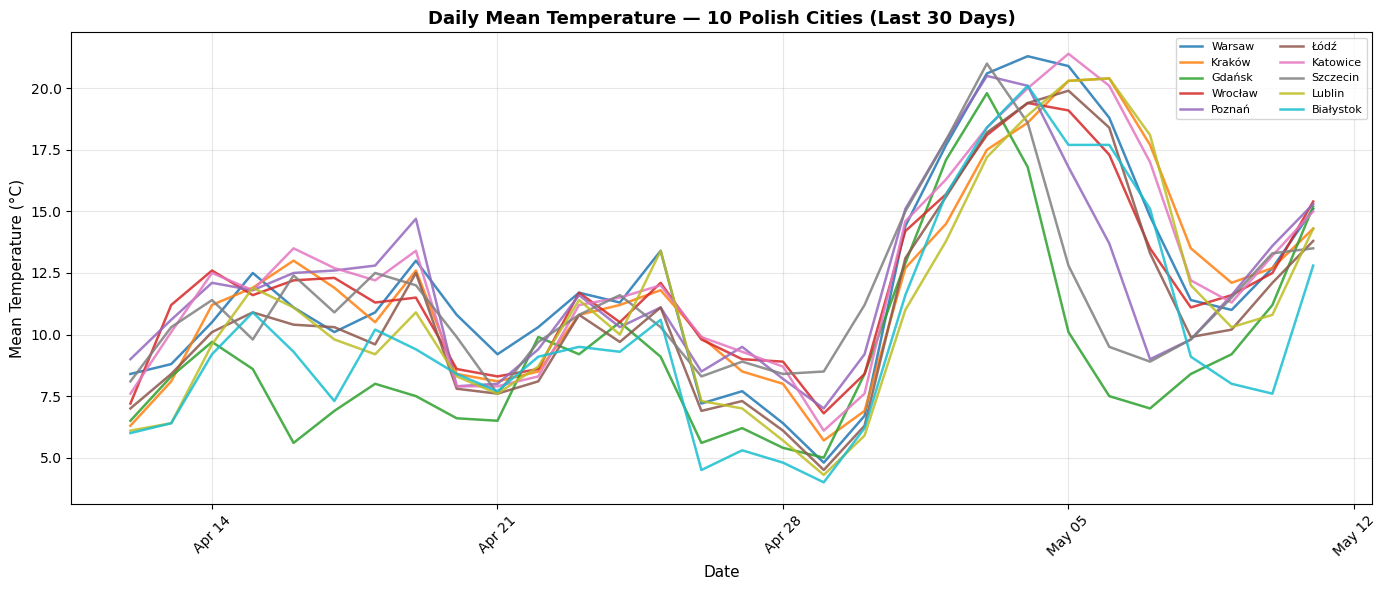

Saved: plot1_temp_trend.png


In [29]:
# ── Plot 1: Daily Temperature Trend (all cities) ──────────────────────────────
# Line chart showing mean temperature for each city over 30 days
fig, ax = plt.subplots(figsize=(14, 6))

colors = sns.color_palette('tab10', len(CITIES))
for i, city in enumerate(df['city'].unique()):
    city_data = df[df['city'] == city].sort_values('date')
    ax.plot(
        city_data['date'], city_data['temp_mean'],
        label=city, linewidth=1.8, alpha=0.85, color=colors[i]
    )

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Mean Temperature (°C)', fontsize=11)
ax.set_title('Daily Mean Temperature — 10 Polish Cities (Last 30 Days)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot1_temp_trend.png', dpi=150, bbox_inches='tight')
plt.show()


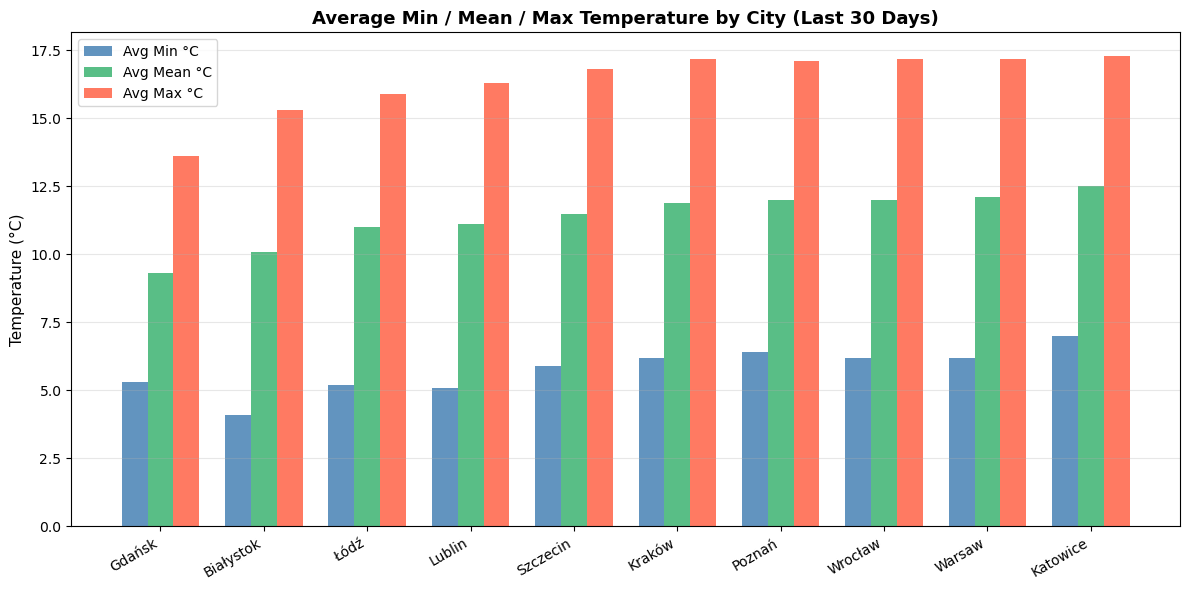

In [31]:
# ── Plot 2: Average Temperature by City (Bar chart) ──────────────────────────
city_temp = city_stats[['avg_temp_min', 'avg_temp_mean', 'avg_temp_max']].sort_values('avg_temp_mean')

x = range(len(city_temp))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar([i - width for i in x], city_temp['avg_temp_min'],  width, label='Avg Min °C', color='steelblue',   alpha=0.85)
ax.bar([i         for i in x], city_temp['avg_temp_mean'], width, label='Avg Mean °C', color='mediumseagreen', alpha=0.85)
ax.bar([i + width for i in x], city_temp['avg_temp_max'],  width, label='Avg Max °C', color='tomato',      alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(city_temp.index, rotation=30, ha='right')
ax.set_ylabel('Temperature (°C)', fontsize=11)
ax.set_title('Average Min / Mean / Max Temperature by City (Last 30 Days)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_avg_temp_by_city.png', dpi=150, bbox_inches='tight')
plt.show()


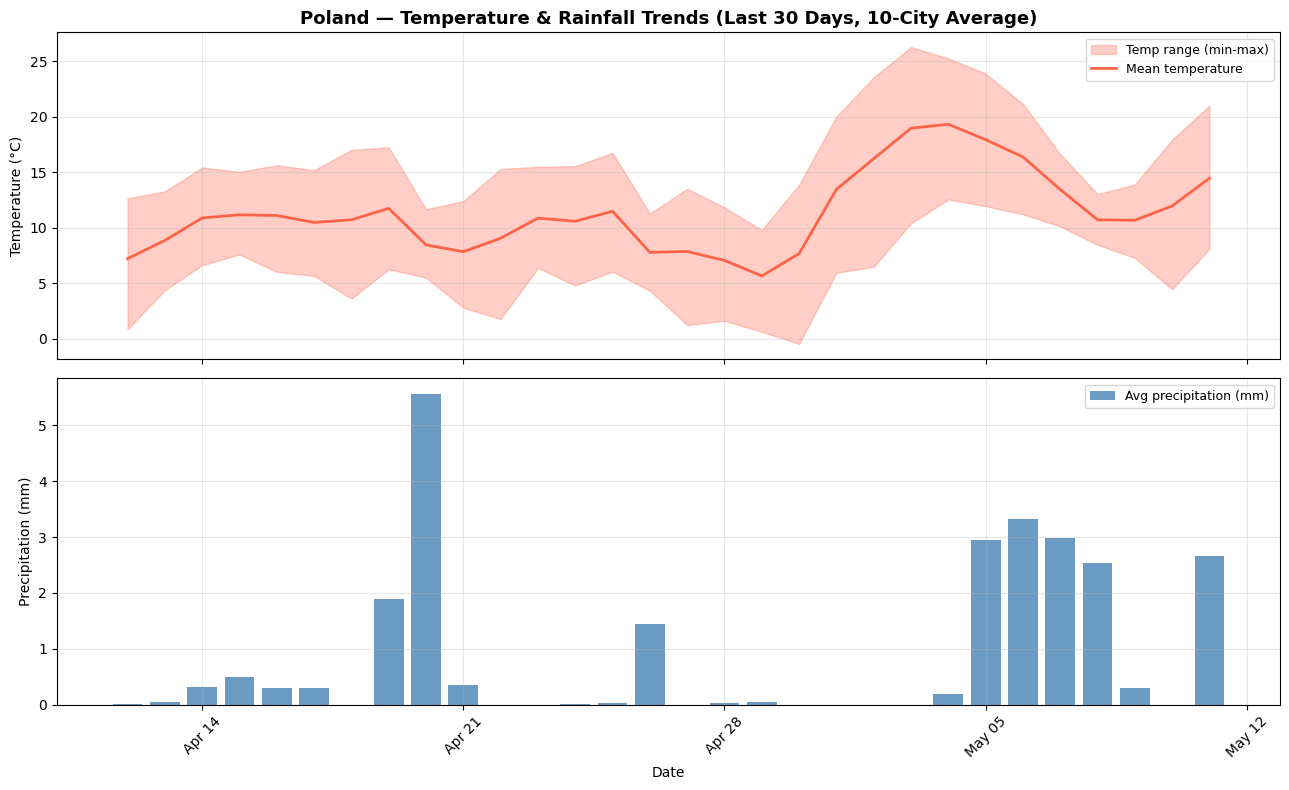

In [33]:
# ── Plot 3: Daily Rainfall Trend (Poland Average) ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Top: temperature band (min to max shaded)
ax1.fill_between(
    daily_avg['date'],
    daily_avg['avg_temp_min'],
    daily_avg['avg_temp_max'],
    alpha=0.3, color='tomato', label='Temp range (min-max)'
)
ax1.plot(daily_avg['date'], daily_avg['avg_temp_mean'],
         color='tomato', linewidth=2, label='Mean temperature')
ax1.set_ylabel('Temperature (°C)', fontsize=10)
ax1.set_title('Poland — Temperature & Rainfall Trends (Last 30 Days, 10-City Average)',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Bottom: rainfall bars
ax2.bar(daily_avg['date'], daily_avg['total_precip'],
        color='steelblue', alpha=0.8, width=0.8, label='Avg precipitation (mm)')
ax2.set_ylabel('Precipitation (mm)', fontsize=10)
ax2.set_xlabel('Date', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plot3_temp_rainfall_trend.png', dpi=150, bbox_inches='tight')
plt.show()


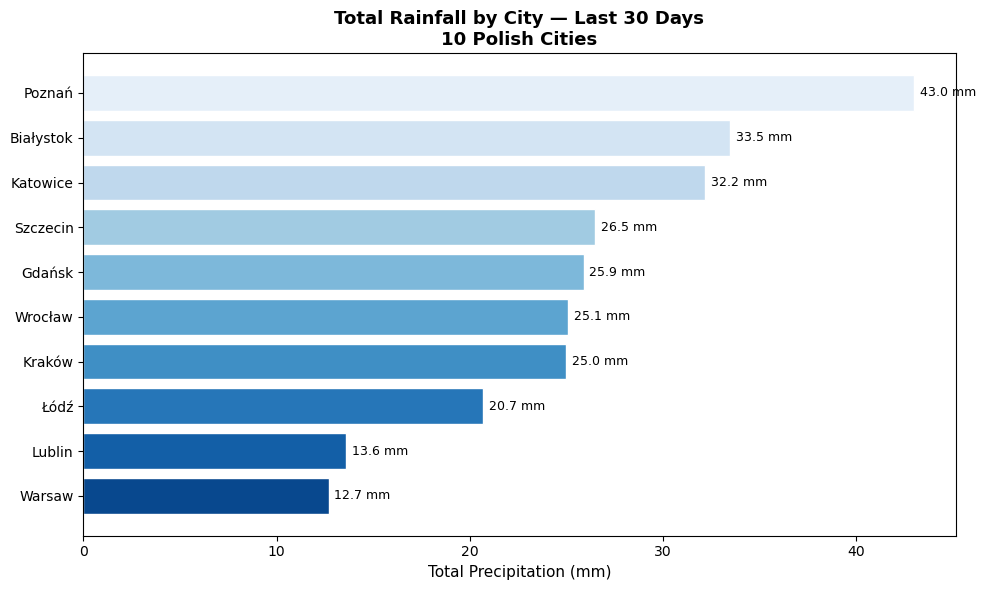

In [35]:
# ── Plot 4: Total Rainfall per City (30 days) ─────────────────────────────────
rain_by_city = city_stats['total_rain'].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    rain_by_city.index, rain_by_city.values,
    color=sns.color_palette('Blues_r', len(rain_by_city)),
    edgecolor='white'
)
for bar, val in zip(bars, rain_by_city.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} mm', va='center', fontsize=9)
ax.set_xlabel('Total Precipitation (mm)', fontsize=11)
ax.set_title('Total Rainfall by City — Last 30 Days\n10 Polish Cities',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_rainfall_by_city.png', dpi=150, bbox_inches='tight')
plt.show()


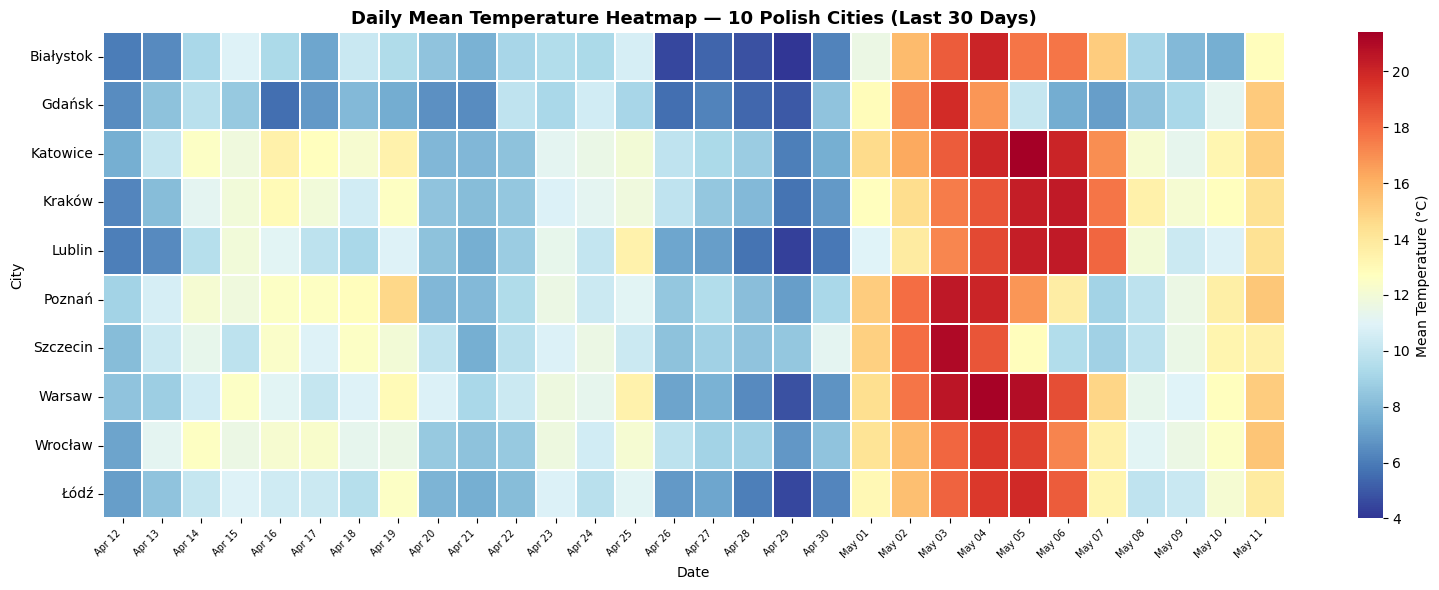

In [37]:
# ── Plot 5: Temperature Heatmap (City × Date) ─────────────────────────────────
# Pivot the data so rows = cities, columns = dates, values = mean temperature
pivot = df.pivot_table(
    index='city', columns='date', values='temp_mean', aggfunc='mean'
)
# Format column labels as 'Apr 01' style
pivot.columns = [d.strftime('%b %d') for d in pivot.columns]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot,
    ax=ax,
    cmap='RdYlBu_r',          # Red = hot, blue = cold
    annot=False,
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'Mean Temperature (°C)'}
)
ax.set_title('Daily Mean Temperature Heatmap — 10 Polish Cities (Last 30 Days)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('City', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('plot5_temp_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


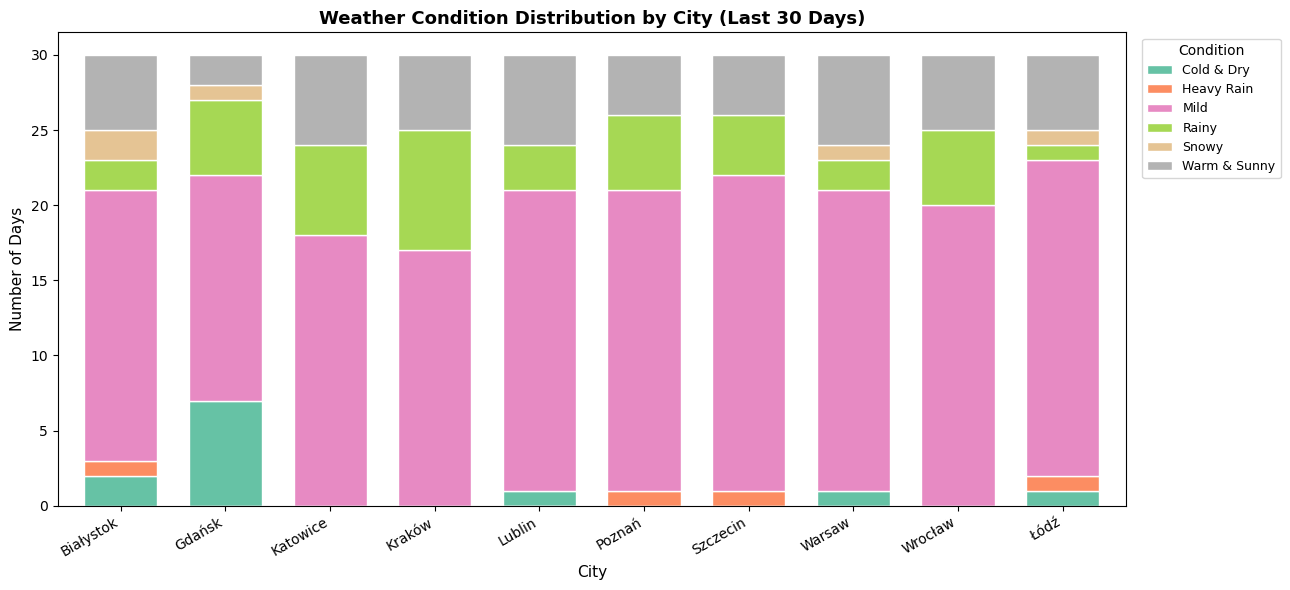

In [39]:
# ── Plot 6: Weather Condition Distribution by City ────────────────────────────
condition_pivot = (
    df.groupby(['city', 'weather_condition'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 6))
condition_pivot.plot(
    kind='bar', ax=ax, stacked=True,
    colormap='Set2', edgecolor='white', width=0.7
)
ax.set_xlabel('City', fontsize=11)
ax.set_ylabel('Number of Days', fontsize=11)
ax.set_title('Weather Condition Distribution by City (Last 30 Days)',
             fontsize=13, fontweight='bold')
ax.legend(title='Condition', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plot6_weather_conditions.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Export Results

In [41]:
# ── Save to CSV ───────────────────────────────────────────────────────────────
df.to_csv('poland_weather_daily.csv', index=False, encoding='utf-8-sig')
print('Saved: poland_weather_daily.csv')

city_stats.to_csv('poland_weather_city_summary.csv', encoding='utf-8-sig')
print('Saved: poland_weather_city_summary.csv')

print('\n' + '='*55)
print('FINAL SUMMARY')
print('='*55)
print(f'  Cities analyzed:        {df["city"].nunique()}')
print(f'  Date range:             {START_STR} → {END_STR}')
print(f'  Total records:          {len(df)} ({len(df)//len(CITIES)} days × {len(CITIES)} cities)')
print(f'  Warmest city:           {city_stats["avg_temp_mean"].idxmax()} ({city_stats["avg_temp_mean"].max():.1f}°C avg)')
print(f'  Coldest city:           {city_stats["avg_temp_mean"].idxmin()} ({city_stats["avg_temp_mean"].min():.1f}°C avg)')
print(f'  Wettest city:           {city_stats["total_rain"].idxmax()} ({city_stats["total_rain"].max():.1f}mm)')
print(f'  Driest city:            {city_stats["total_rain"].idxmin()} ({city_stats["total_rain"].min():.1f}mm)')
print(f'  Hottest day recorded:   {df.loc[df["temp_max"].idxmax(), "temp_max"]:.1f}°C in {df.loc[df["temp_max"].idxmax(), "city"]}')
print(f'  Coldest day recorded:   {df.loc[df["temp_min"].idxmin(), "temp_min"]:.1f}°C in {df.loc[df["temp_min"].idxmin(), "city"]}')
print('='*55)


Saved: poland_weather_daily.csv
Saved: poland_weather_city_summary.csv

FINAL SUMMARY
  Cities analyzed:        10
  Date range:             2026-04-12 → 2026-05-11
  Total records:          300 (30 days × 10 cities)
  Warmest city:           Katowice (12.5°C avg)
  Coldest city:           Gdańsk (9.3°C avg)
  Wettest city:           Poznań (43.0mm)
  Driest city:            Warsaw (12.7mm)
  Hottest day recorded:   28.8°C in Gdańsk
  Coldest day recorded:   -2.8°C in Łódź
